# WRDS Corporate Bond Relative Value Assignment

This notebook prepares a reproducible relative-value analysis using the attached WRDS enhanced end-of-month corporate bond return files.

The assignment requirements used here are:

1. Use WRDS enhanced end-of-month data for at least four large issuers over a period longer than one year.
2. Filter bonds so the cross-section for each issuer uses consistent `SECURITY_LEVEL` and rating values.
3. Plot Treasury spread (`T_Spread`) against duration for each issuer.
4. Fit an issuer-level spread curve and use residuals to identify rich and cheap bonds.
5. Build a duration-neutral portfolio that shorts rich bonds and longs cheap bonds.
6. Evaluate next-month return, PnL, turnover, and summarize findings.

The analysis below uses the screenshot as assignment specifications, not as instructions to the notebook. The top parameter cell is intentionally easy to edit.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from sklearn.linear_model import LinearRegression

warnings.filterwarnings("ignore", category=FutureWarning)

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:,.4f}".format

## Parameters

The selected issuers are large, recognizable non-financial issuers with enough bonds in the supplied files to cover a usable maturity and duration spectrum. The sample starts at August 2022 because all selected issuers are available by then and runs through March 2025 for a common end date across the selected group.

In [2]:
DATA_DIR = Path("data")
CSV_FILES = [
    DATA_DIR / "WRDS_Data-Systematic_Trading-Fall2026-1.csv",
    DATA_DIR / "WRDS_Data-Systematic_Trading-Fall2026-2.csv",
]

SELECTED_ISSUERS = ["AAPL", "AMZN", "BA", "CAT", "DIS", "T"]
START_DATE = "2022-08-31"
END_DATE = "2025-03-31"

MIN_BONDS_PER_FIT = 8
TOP_N_PER_SIDE = 3
ANALYSIS_DATE = None  # None chooses the latest common date with enough fitted bonds.

USE_VOLUME_WEIGHTS = True
SPREAD_BPS_LIMIT = (-100, 2_000)
DURATION_LIMIT = (0.05, 35.0)
PRICE_LIMIT = (20.0, 200.0)

missing_files = [str(p) for p in CSV_FILES if not p.exists()]
if missing_files:
    raise FileNotFoundError(f"Missing data files: {missing_files}")

print("Input files:")
for p in CSV_FILES:
    print(f"  {p} ({p.stat().st_size / 1_000_000:.1f} MB)")

Input files:
  data\WRDS_Data-Systematic_Trading-Fall2026-1.csv (10.0 MB)
  data\WRDS_Data-Systematic_Trading-Fall2026-2.csv (11.5 MB)


## Helper Functions

The WRDS download stores several numeric fields as strings with percent signs, dollar signs, or commas. The functions below convert them to numeric values and keep the original data logic visible.

In [3]:
def parse_percent_to_decimal(value):
    """Convert strings such as '.3171%' or '0.10%' to decimal returns/rates."""
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float, np.number)):
        return float(value)
    s = str(value).strip().replace(",", "")
    if s in {"", ".", "nan", "NaN", "NR"}:
        return np.nan
    if s.endswith("%"):
        s = s[:-1]
        try:
            return float(s) / 100.0
        except ValueError:
            return np.nan
    try:
        return float(s)
    except ValueError:
        return np.nan


def parse_money(value):
    """Convert strings such as '$22,122,786' to floats."""
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float, np.number)):
        return float(value)
    s = str(value).strip().replace("$", "").replace(",", "")
    if s in {"", ".", "nan", "NaN", "NR"}:
        return np.nan
    try:
        return float(s)
    except ValueError:
        return np.nan


def weighted_std(values, weights=None):
    values = np.asarray(values, dtype=float)
    good = np.isfinite(values)
    if weights is None:
        return np.nanstd(values[good], ddof=1) if good.sum() > 1 else np.nan
    weights = np.asarray(weights, dtype=float)
    good = good & np.isfinite(weights) & (weights > 0)
    if good.sum() <= 1:
        return np.nan
    avg = np.average(values[good], weights=weights[good])
    var = np.average((values[good] - avg) ** 2, weights=weights[good])
    return np.sqrt(var)


def choose_mode(series):
    clean = series.dropna()
    if clean.empty:
        return np.nan
    return clean.mode().iloc[0]


def make_weights(group):
    if not USE_VOLUME_WEIGHTS:
        return np.ones(len(group))
    base = group["T_DVolume_num"].copy()
    fallback = group["AMOUNT_OUTSTANDING"].copy()
    base = base.where(base > 0, fallback)
    w = np.sqrt(base.clip(lower=0))
    if w.notna().sum() == 0 or w.fillna(0).sum() <= 0:
        return np.ones(len(group))
    lo, hi = w.dropna().quantile([0.05, 0.95])
    if np.isfinite(lo) and np.isfinite(hi) and hi > lo:
        w = w.clip(lower=lo, upper=hi)
    return w.fillna(w.median()).to_numpy()

## Load and Clean Data

The key transformations are:

- Convert WRDS string fields to numeric rates, basis points, prices, and dollar volumes.
- Keep the selected issuer/date range.
- Remove observations with missing or implausible spread, duration, price, and maturity data.
- For each issuer-month, retain the modal `SECURITY_LEVEL` and modal `RATING_CAT`. This keeps the cross-section internally consistent while still allowing a rating to change through time.

In [4]:
usecols = [
    "DATE", "ISSUE_ID", "CUSIP", "bond_sym_id", "ISIN", "company_symbol",
    "BOND_TYPE", "SECURITY_LEVEL", "CONV", "OFFERING_DATE", "OFFERING_AMT",
    "PRINCIPAL_AMT", "MATURITY", "COUPON", "AMOUNT_OUTSTANDING",
    "R_SP", "R_MR", "R_FR", "RATING_NUM", "RATING_CAT", "RATING_CLASS",
    "T_DATE", "T_Volume", "T_DVolume", "T_Spread", "T_Yld_Pt", "YIELD",
    "PRICE_EOM", "COUPAMT", "COUPACC", "RET_EOM", "TMT", "DURATION",
    "DEFAULTED",
]

raw = pd.concat([pd.read_csv(path, usecols=usecols) for path in CSV_FILES], ignore_index=True)

df = raw.copy()
date_cols = ["DATE", "OFFERING_DATE", "MATURITY", "T_DATE"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

df["T_Spread_dec"] = df["T_Spread"].map(parse_percent_to_decimal)
df["T_Spread_bps"] = df["T_Spread_dec"] * 10_000
df["YIELD_dec"] = df["YIELD"].map(parse_percent_to_decimal)
df["RET_EOM_dec"] = df["RET_EOM"].map(parse_percent_to_decimal)
df["T_DVolume_num"] = df["T_DVolume"].map(parse_money)
df["T_Volume_num"] = df["T_Volume"].map(parse_money)

numeric_cols = [
    "ISSUE_ID", "OFFERING_AMT", "PRINCIPAL_AMT", "COUPON",
    "AMOUNT_OUTSTANDING", "RATING_NUM", "T_Yld_Pt", "PRICE_EOM",
    "COUPAMT", "COUPACC", "TMT", "DURATION",
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

selected = df[
    df["company_symbol"].isin(SELECTED_ISSUERS)
    & (df["DATE"] >= pd.Timestamp(START_DATE))
    & (df["DATE"] <= pd.Timestamp(END_DATE))
].copy()

initial_rows = len(selected)

selected = selected[
    (selected["DEFAULTED"].fillna("N") != "Y")
    & (selected["CONV"].fillna(0) == 0)
    & selected["T_Spread_bps"].between(*SPREAD_BPS_LIMIT)
    & selected["DURATION"].between(*DURATION_LIMIT)
    & selected["PRICE_EOM"].between(*PRICE_LIMIT)
    & (selected["TMT"] > 0)
    & selected["COUPON"].notna()
].copy()

selected["modal_security_level"] = selected.groupby(["company_symbol", "DATE"])["SECURITY_LEVEL"].transform(choose_mode)
selected["modal_rating_cat"] = selected.groupby(["company_symbol", "DATE"])["RATING_CAT"].transform(choose_mode)

filtered = selected[
    (selected["SECURITY_LEVEL"] == selected["modal_security_level"])
    & (selected["RATING_CAT"] == selected["modal_rating_cat"])
].copy()

filtered = filtered.sort_values(["company_symbol", "DATE", "ISSUE_ID"]).reset_index(drop=True)
filtered["month"] = filtered["DATE"].dt.to_period("M")

print(f"Rows for selected issuers before cleaning: {initial_rows:,}")
print(f"Rows after data-quality and consistency filters: {len(filtered):,}")
display(
    filtered.groupby("company_symbol").agg(
        rows=("ISSUE_ID", "size"),
        bonds=("ISSUE_ID", "nunique"),
        first_date=("DATE", "min"),
        last_date=("DATE", "max"),
        median_duration=("DURATION", "median"),
        median_spread_bps=("T_Spread_bps", "median"),
    )
)

Rows for selected issuers before cleaning: 10,689
Rows after data-quality and consistency filters: 9,712


,rows,bonds,first_date,last_date,median_duration,median_spread_bps
company_symbol,,,,,,
AAPL,1623,57,2022-08-31,2025-03-31,6.4100,17.0000
AMZN,1019,37,2022-08-31,2025-03-31,5.4800,14.0000
BA,1542,60,2022-08-31,2025-03-31,6.4900,27.0000
CAT,1251,61,2022-08-31,2025-03-31,2.6100,11.0000
DIS,1592,59,2022-08-31,2025-03-31,6.8950,19.0000
T,2685,102,2022-08-31,2025-03-31,9.2100,31.0000


In [5]:
consistency_check = filtered.groupby(["company_symbol", "DATE"]).agg(
    security_levels=("SECURITY_LEVEL", "nunique"),
    rating_cats=("RATING_CAT", "nunique"),
    bonds=("ISSUE_ID", "nunique"),
).reset_index()

print("Consistency-filter check. The first two columns should be 1 for every issuer-month.")
display(consistency_check[["security_levels", "rating_cats", "bonds"]].describe())

Consistency-filter check. The first two columns should be 1 for every issuer-month.


,security_levels,rating_cats,bonds
count,192.0000,192.0000,192.0000
mean,1.0000,1.0000,50.5833
std,0.0000,0.0000,16.5730
min,1.0000,1.0000,27.0000
25%,1.0000,1.0000,39.0000
50%,1.0000,1.0000,48.0000
75%,1.0000,1.0000,52.0000
max,1.0000,1.0000,91.0000


## Next-Month Return

Positions are formed at month-end using the fitted residual at that date. The next-month return is the next `RET_EOM` observation for the same issue when the next observation is within a normal monthly gap.

`RET_EOM` is used as the primary return because it is the WRDS enhanced monthly bond return field. If a return is missing but the next price is present, the notebook uses an approximate price return plus one month of coupon accrual: `COUPON / 12`.

In [6]:
filtered = filtered.sort_values(["ISSUE_ID", "DATE"]).copy()
filtered["next_date"] = filtered.groupby("ISSUE_ID")["DATE"].shift(-1)
filtered["next_price"] = filtered.groupby("ISSUE_ID")["PRICE_EOM"].shift(-1)
filtered["next_ret_eom"] = filtered.groupby("ISSUE_ID")["RET_EOM_dec"].shift(-1)

gap_days = (filtered["next_date"] - filtered["DATE"]).dt.days
valid_next_month = gap_days.between(25, 45)

approx_price_return = (filtered["next_price"] - filtered["PRICE_EOM"]) / filtered["PRICE_EOM"]
monthly_coupon_accrual = (filtered["COUPON"] / 100.0) / 12.0
filtered["next_ret_approx_with_accrual"] = approx_price_return + monthly_coupon_accrual

filtered["next_return"] = np.where(
    valid_next_month,
    filtered["next_ret_eom"].where(filtered["next_ret_eom"].notna(), filtered["next_ret_approx_with_accrual"]),
    np.nan,
)
filtered["next_return_source"] = np.where(
    valid_next_month & filtered["next_ret_eom"].notna(),
    "RET_EOM",
    np.where(valid_next_month & filtered["next_ret_approx_with_accrual"].notna(), "price_plus_accrual", "unavailable"),
)

display(filtered["next_return_source"].value_counts(dropna=False).to_frame("rows"))

,rows
next_return_source,
RET_EOM,9131
unavailable,581


## Spread Curve Model

For each issuer-month, the fitted curve is:

`T_Spread_bps = b0 + b1 * log(1 + DURATION) + b2 * DURATION + b3 * COUPON`

This is a three-factor model plus intercept. Duration is used instead of raw maturity because the portfolio is duration-neutral and duration better reflects rate exposure. Coupon is included because high-coupon bonds can trade differently because of price, call, liquidity, and tax/clientele effects. Fitting is weighted by trading dollar volume, with mild winsorization of weights so one trade does not dominate the curve.

In [7]:
def fit_curve_one_group(group):
    group = group.copy()
    group["fit_ok"] = False
    group["spread_fit_bps"] = np.nan
    group["resid_bps"] = np.nan
    group["resid_z"] = np.nan

    fit_group = group.dropna(subset=["T_Spread_bps", "DURATION", "COUPON", "PRICE_EOM"])
    if len(fit_group) < MIN_BONDS_PER_FIT:
        return group, None

    X = np.column_stack([
        np.log1p(fit_group["DURATION"].to_numpy()),
        fit_group["DURATION"].to_numpy(),
        fit_group["COUPON"].to_numpy(),
    ])
    y = fit_group["T_Spread_bps"].to_numpy()
    weights = make_weights(fit_group)

    if np.unique(np.round(y, 8)).size < 2:
        return group, None

    model = LinearRegression()
    model.fit(X, y, sample_weight=weights)
    pred = model.predict(X)
    resid = y - pred
    resid_scale = weighted_std(resid, weights)
    if not np.isfinite(resid_scale) or resid_scale <= 0:
        resid_scale = np.nanstd(resid, ddof=1)
    if not np.isfinite(resid_scale) or resid_scale <= 0:
        resid_scale = 1.0

    idx = fit_group.index
    group.loc[idx, "fit_ok"] = True
    group.loc[idx, "spread_fit_bps"] = pred
    group.loc[idx, "resid_bps"] = resid
    group.loc[idx, "resid_z"] = resid / resid_scale

    stats = {
        "company_symbol": fit_group["company_symbol"].iloc[0],
        "DATE": fit_group["DATE"].iloc[0],
        "n_bonds": len(fit_group),
        "r2": model.score(X, y, sample_weight=weights),
        "b0": model.intercept_,
        "b_log_duration": model.coef_[0],
        "b_duration": model.coef_[1],
        "b_coupon": model.coef_[2],
        "resid_std_bps": resid_scale,
    }
    return group, stats


fit_parts = []
stats_rows = []
for _, group in filtered.groupby(["company_symbol", "DATE"], sort=True):
    fitted_group, stats = fit_curve_one_group(group)
    fit_parts.append(fitted_group)
    if stats is not None:
        stats_rows.append(stats)

fitted = pd.concat(fit_parts, ignore_index=True)
model_stats = pd.DataFrame(stats_rows)

display(
    model_stats.groupby("company_symbol").agg(
        fit_months=("DATE", "nunique"),
        avg_bonds=("n_bonds", "mean"),
        median_r2=("r2", "median"),
        median_resid_std_bps=("resid_std_bps", "median"),
    )
)

,fit_months,avg_bonds,median_r2,median_resid_std_bps
company_symbol,,,,
AAPL,32,50.7188,0.7393,5.9802
AMZN,32,31.8438,0.7674,4.8826
BA,32,48.1875,0.2693,14.7486
CAT,32,39.0938,0.5137,7.1943
DIS,32,49.7500,0.4322,10.0353
T,32,83.9062,0.3151,20.8823


In [8]:
if ANALYSIS_DATE is None:
    common_dates = (
        model_stats.groupby("DATE")["company_symbol"]
        .nunique()
        .loc[lambda s: s >= len(SELECTED_ISSUERS)]
    )
    if common_dates.empty:
        common_dates = model_stats.groupby("DATE")["company_symbol"].nunique().loc[lambda s: s >= 4]
    analysis_date = common_dates.index.max()
else:
    analysis_date = pd.Timestamp(ANALYSIS_DATE)

print(f"Analysis date for cross-sectional plots: {analysis_date.date()}")
display(
    model_stats[model_stats["DATE"].eq(analysis_date)]
    .sort_values("company_symbol")
    [["company_symbol", "n_bonds", "r2", "resid_std_bps", "b0", "b_log_duration", "b_duration", "b_coupon"]]
)

Analysis date for cross-sectional plots: 2025-03-31


,company_symbol,n_bonds,r2,resid_std_bps,b0,b_log_duration,b_duration,b_coupon
31,AAPL,47,0.7769,4.2024,8.5448,-1.4102,1.4946,-0.7465
63,AMZN,27,0.7417,4.0432,9.5207,-4.9241,1.7711,-0.2332
95,BA,48,0.2494,10.1195,5.3158,7.0298,0.1232,-0.2044
127,CAT,40,0.4432,6.2471,1.1724,4.1833,0.4537,0.5688
159,DIS,46,0.5410,6.7334,5.6008,-6.4044,2.1719,1.8436
191,T,86,0.3716,13.6544,-6.2884,-7.2115,2.2225,5.7976


## Spread vs. Duration by Issuer

The scatter points are individual bonds on the selected analysis date. The line is the fitted curve from the cross-sectional model for that issuer-month.

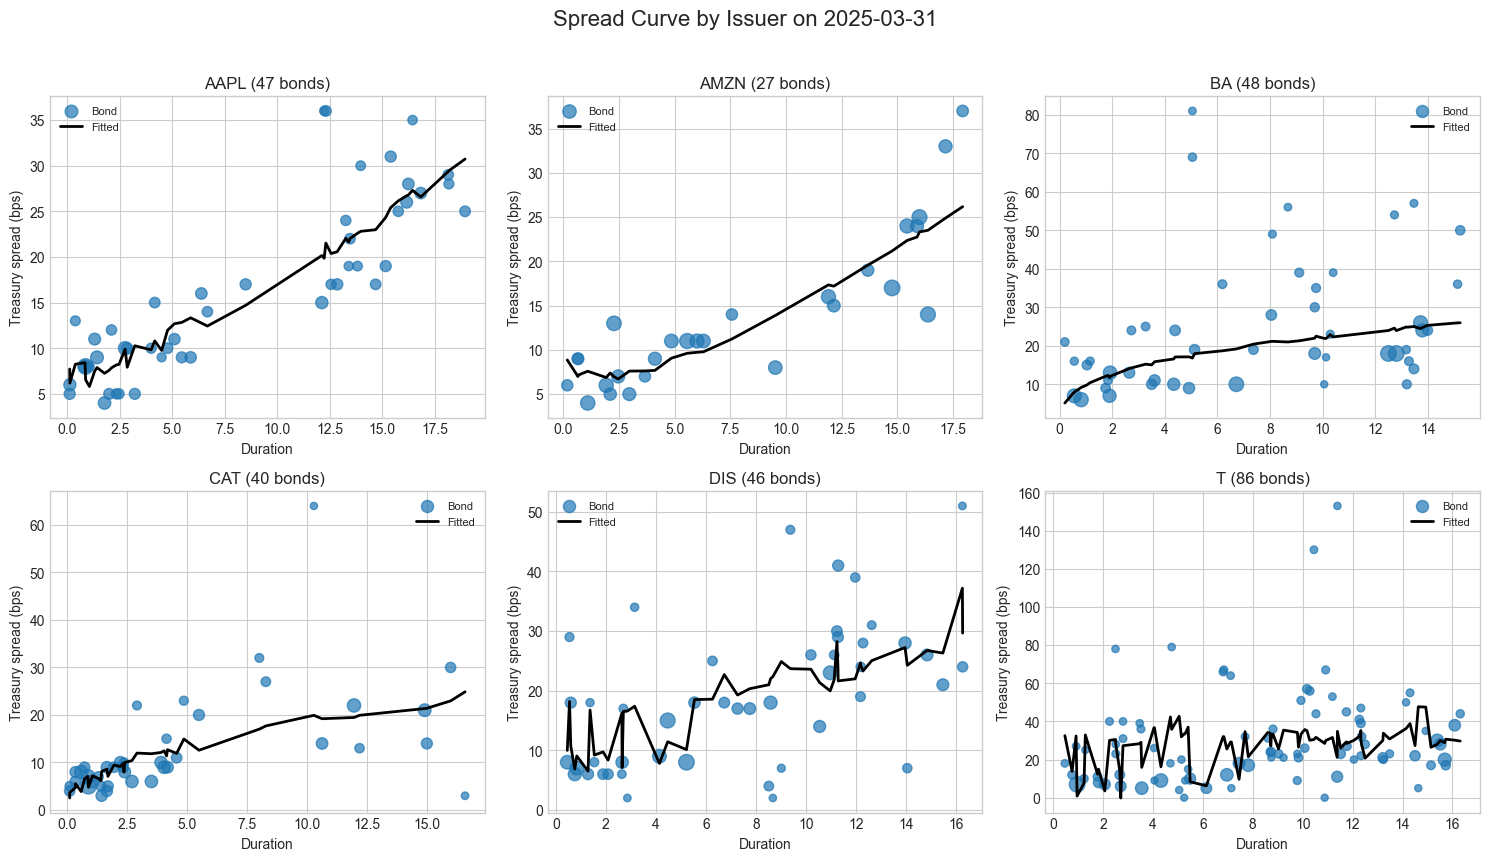

In [9]:
plot_df = fitted[(fitted["DATE"] == analysis_date) & fitted["fit_ok"]].copy()

n_issuers = len(SELECTED_ISSUERS)
ncols = 3
nrows = int(np.ceil(n_issuers / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4.2 * nrows), sharex=False, sharey=False)
axes = np.array(axes).reshape(-1)

for ax, issuer in zip(axes, SELECTED_ISSUERS):
    g = plot_df[plot_df["company_symbol"] == issuer].sort_values("DURATION")
    if g.empty:
        ax.set_title(f"{issuer}: no fitted data")
        ax.axis("off")
        continue
    size = np.sqrt(g["T_DVolume_num"].fillna(0).clip(lower=0))
    if size.max() > 0:
        size = 25 + 100 * size / size.max()
    else:
        size = 45
    ax.scatter(g["DURATION"], g["T_Spread_bps"], s=size, alpha=0.70, label="Bond")
    ax.plot(g["DURATION"], g["spread_fit_bps"], color="black", linewidth=2.0, label="Fitted")
    ax.set_title(f"{issuer} ({len(g)} bonds)")
    ax.set_xlabel("Duration")
    ax.set_ylabel("Treasury spread (bps)")
    ax.legend(loc="best", fontsize=8)

for ax in axes[n_issuers:]:
    ax.axis("off")

fig.suptitle(f"Spread Curve by Issuer on {analysis_date.date()}", fontsize=16, y=1.02)
fig.tight_layout()
plt.show()

## Rich and Cheap Bonds

Residuals are measured as actual spread minus fitted spread:

- Positive residual: the bond trades wider than the curve and is classified as cheap.
- Negative residual: the bond trades tighter than the curve and is classified as rich.

The table below shows the most extreme residuals on the analysis date.

In [10]:
snapshot = plot_df.copy()
snapshot["rich_cheap"] = np.where(snapshot["resid_bps"] > 0, "cheap", "rich")
outlier_table = (
    snapshot.assign(abs_resid=lambda x: x["resid_bps"].abs())
    .sort_values(["company_symbol", "abs_resid"], ascending=[True, False])
    .groupby("company_symbol")
    .head(6)
    [[
        "company_symbol", "CUSIP", "MATURITY", "SECURITY_LEVEL", "RATING_CAT",
        "COUPON", "DURATION", "TMT", "PRICE_EOM", "T_Spread_bps",
        "spread_fit_bps", "resid_bps", "resid_z", "rich_cheap",
        "T_DVolume_num", "AMOUNT_OUTSTANDING",
    ]]
    .sort_values(["company_symbol", "resid_bps"], ascending=[True, False])
)
display(outlier_table)

,company_symbol,CUSIP,MATURITY,SECURITY_LEVEL,RATING_CAT,COUPON,DURATION,TMT,PRICE_EOM,T_Spread_bps,spread_fit_bps,resid_bps,resid_z,rich_cheap,T_DVolume_num,AMOUNT_OUTSTANDING
1577,AAPL,037833AT7,2044-05-06,SEN,AA,4.4500,12.2300,19.3800,92.2900,36.0000,19.8602,16.1398,3.8406,cheap,"20,807,341.0000","1,000,000.0000"
1607,AAPL,037833EE6,2041-02-08,SEN,AA,2.3750,12.3100,16.0900,70.2400,36.0000,21.5203,14.4797,3.4456,cheap,"79,582,495.0000","1,500,000.0000"
1602,AAPL,037833DZ0,2050-08-20,SEN,AA,2.4000,16.4400,25.7600,59.8700,35.0000,27.2933,7.7067,1.8339,cheap,"28,309,879.0000","1,250,000.0000"
1591,AAPL,037833DD9,2047-09-12,SEN,AA,3.7500,13.9700,22.7800,79.2100,30.0000,22.8092,7.1908,1.7111,cheap,"34,407,947.0000","1,000,000.0000"
1603,AAPL,037833EA4,2060-08-20,SEN,AA,2.5500,18.9400,35.9100,59.0600,25.0000,30.7290,-5.7290,-1.3633,rich,"72,485,993.0000","1,750,000.0000"
1622,AAPL,037833EW6,2053-05-10,SEN,AA,4.8500,14.6800,28.5200,95.8000,17.0000,22.9838,-5.9838,-1.4239,rich,"68,199,562.0000","1,250,000.0000"
2626,AMZN,023135BU9,2060-06-03,SEN,AA,2.7000,17.9400,35.6900,58.0300,37.0000,26.1808,10.8192,2.6759,cheap,"49,920,298.0000","2,000,000.0000"
2630,AMZN,023135CC8,2061-05-12,SEN,AA,3.2500,17.1700,36.6400,65.8200,33.0000,24.8932,8.1068,2.0051,cheap,"104,931,881.0000","1,750,000.0000"
2618,AMZN,023135BC9,2027-08-22,SEN,AA,3.1500,2.2700,2.4300,97.7800,13.0000,6.9724,6.0276,1.4908,cheap,"183,378,367.0000","3,500,000.0000"
2636,AMZN,023135CJ3,2052-04-13,SEN,AA,3.9500,14.7700,27.4300,79.5000,17.0000,21.1770,-4.1770,-1.0331,rich,"259,636,243.0000","2,500,000.0000"


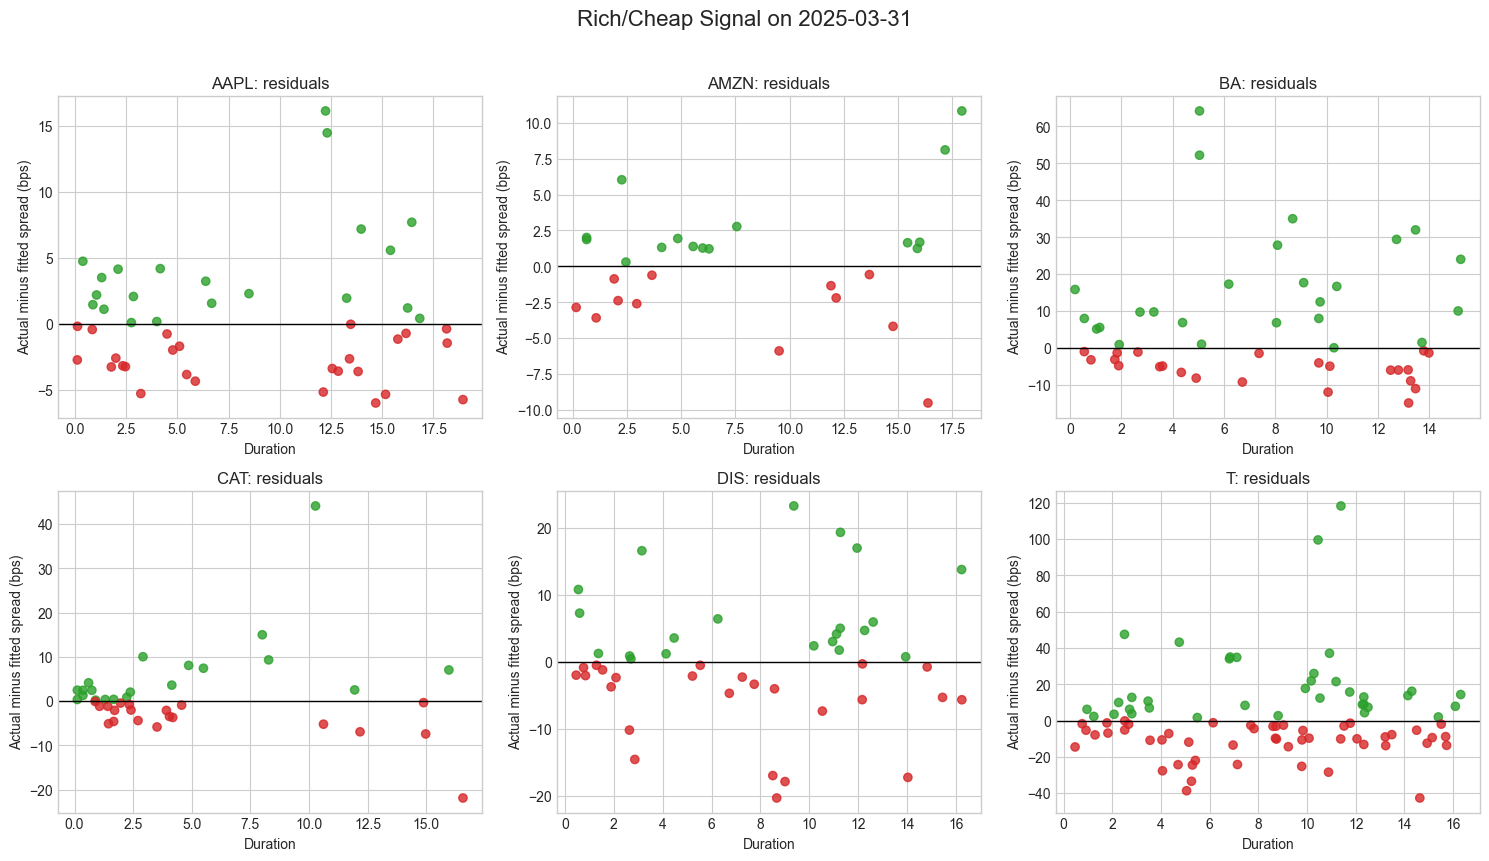

In [11]:
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4.2 * nrows), sharex=False, sharey=False)
axes = np.array(axes).reshape(-1)

for ax, issuer in zip(axes, SELECTED_ISSUERS):
    g = snapshot[snapshot["company_symbol"] == issuer].copy()
    if g.empty:
        ax.axis("off")
        continue
    colors = np.where(g["resid_bps"] >= 0, "tab:green", "tab:red")
    ax.axhline(0, color="black", linewidth=1)
    ax.scatter(g["DURATION"], g["resid_bps"], c=colors, alpha=0.8)
    ax.set_title(f"{issuer}: residuals")
    ax.set_xlabel("Duration")
    ax.set_ylabel("Actual minus fitted spread (bps)")

for ax in axes[n_issuers:]:
    ax.axis("off")

fig.suptitle(f"Rich/Cheap Signal on {analysis_date.date()}", fontsize=16, y=1.02)
fig.tight_layout()
plt.show()

## Duration-Neutral Portfolio Construction

At each issuer-month:

1. Long the `TOP_N_PER_SIDE` cheapest bonds by residual z-score.
2. Short the `TOP_N_PER_SIDE` richest bonds by residual z-score.
3. Scale the short side so that `sum(position * price * duration)` is approximately zero.
4. Normalize absolute market value exposure to 1 for each issuer-month.
5. Evaluate the position using the next month return.

The position is expressed as a signed face-value weight. The realized portfolio return is calculated from signed market-value weights.

In [12]:
def build_portfolio_one_group(group):
    group = group.dropna(subset=["resid_z", "PRICE_EOM", "DURATION", "next_return"]).copy()
    if len(group) < max(MIN_BONDS_PER_FIT, 2 * TOP_N_PER_SIDE):
        return pd.DataFrame()

    longs = group.nlargest(TOP_N_PER_SIDE, "resid_z").copy()
    shorts = group.nsmallest(TOP_N_PER_SIDE, "resid_z").copy()
    if set(longs.index).intersection(set(shorts.index)):
        return pd.DataFrame()

    longs["side"] = "long cheap"
    shorts["side"] = "short rich"
    port = pd.concat([longs, shorts], axis=0).copy()
    port["raw_signal"] = np.where(port["side"].eq("long cheap"), port["resid_z"].clip(lower=0), (-port["resid_z"]).clip(lower=0))
    port["raw_signal"] = port["raw_signal"].where(port["raw_signal"] > 0, 1.0)

    price_scale = port["PRICE_EOM"] / 100.0
    long_mask = port["side"].eq("long cheap")
    short_mask = ~long_mask
    long_dur = (port.loc[long_mask, "raw_signal"] * price_scale.loc[long_mask] * port.loc[long_mask, "DURATION"]).sum()
    short_dur = (port.loc[short_mask, "raw_signal"] * price_scale.loc[short_mask] * port.loc[short_mask, "DURATION"]).sum()
    if not np.isfinite(long_dur) or not np.isfinite(short_dur) or long_dur <= 0 or short_dur <= 0:
        return pd.DataFrame()

    short_scale = long_dur / short_dur
    port["position_face"] = np.where(
        long_mask,
        port["raw_signal"],
        -port["raw_signal"] * short_scale,
    )
    gross_market_value = (port["position_face"].abs() * price_scale).sum()
    if not np.isfinite(gross_market_value) or gross_market_value <= 0:
        return pd.DataFrame()

    port["position_face"] = port["position_face"] / gross_market_value
    port["market_weight"] = port["position_face"] * price_scale
    port["duration_contribution"] = port["market_weight"] * port["DURATION"]
    port["return_contribution"] = port["market_weight"] * port["next_return"]
    return port


position_parts = []
for _, group in fitted.groupby(["company_symbol", "DATE"], sort=True):
    p = build_portfolio_one_group(group)
    if not p.empty:
        position_parts.append(p)

positions = pd.concat(position_parts, ignore_index=True)

issuer_month_returns = (
    positions.groupby(["company_symbol", "DATE"])
    .agg(
        portfolio_return=("return_contribution", "sum"),
        gross_market_value=("market_weight", lambda x: x.abs().sum()),
        net_market_value=("market_weight", "sum"),
        portfolio_duration=("duration_contribution", "sum"),
        n_positions=("ISSUE_ID", "size"),
        avg_abs_resid_bps=("resid_bps", lambda x: x.abs().mean()),
    )
    .reset_index()
)

print(f"Built {len(positions):,} bond-month positions across {len(issuer_month_returns):,} issuer-month portfolios.")
display(issuer_month_returns.head())

Built 1,116 bond-month positions across 186 issuer-month portfolios.


,company_symbol,DATE,portfolio_return,gross_market_value,net_market_value,portfolio_duration,n_positions,avg_abs_resid_bps
0,AAPL,2022-08-31,-0.0003,1.0000,0.0436,0.0000,6,20.3606
1,AAPL,2022-09-30,-0.0027,1.0000,0.0130,0.0000,6,24.9088
2,AAPL,2022-10-31,0.0025,1.0000,-0.0010,-0.0000,6,18.9105
3,AAPL,2022-11-30,-0.0027,1.0000,-0.0357,-0.0000,6,19.9146
4,AAPL,2022-12-31,-0.0061,1.0000,-0.1305,0.0000,6,14.4113


In [13]:
def calculate_turnover(pos):
    frames = []
    for issuer, g in pos.groupby("company_symbol"):
        pivot = (
            g.pivot_table(index="DATE", columns="ISSUE_ID", values="market_weight", aggfunc="sum")
            .sort_index()
            .fillna(0.0)
        )
        turnover = 0.5 * pivot.diff().abs().sum(axis=1)
        turnover.iloc[0] = np.nan
        frames.append(pd.DataFrame({"company_symbol": issuer, "DATE": turnover.index, "turnover": turnover.values}))
    return pd.concat(frames, ignore_index=True)


turnover = calculate_turnover(positions)
issuer_month_returns = issuer_month_returns.merge(turnover, on=["company_symbol", "DATE"], how="left")

combined_returns = (
    issuer_month_returns
    .groupby("DATE")
    .agg(
        portfolio_return=("portfolio_return", "mean"),
        turnover=("turnover", "mean"),
        portfolio_duration=("portfolio_duration", "mean"),
        issuers=("company_symbol", "nunique"),
    )
    .reset_index()
)

display(issuer_month_returns.tail())
display(combined_returns.tail())

,company_symbol,DATE,portfolio_return,gross_market_value,net_market_value,portfolio_duration,n_positions,avg_abs_resid_bps,turnover
181,T,2024-10-31,0.0091,1.0000,-0.2175,-0.0000,6,56.9482,0.8119
182,T,2024-11-30,-0.0034,1.0000,-0.3971,0.0000,6,84.6244,0.8029
183,T,2024-12-31,0.0051,1.0000,-0.0533,-0.0000,6,77.8443,0.9396
184,T,2025-01-31,-0.0023,1.0000,-0.4677,0.0000,6,76.6774,1.0000
185,T,2025-02-28,0.0162,1.0000,0.1809,0.0000,6,68.6648,1.0000


,DATE,portfolio_return,turnover,portfolio_duration,issuers
26,2024-10-31,0.0024,0.8571,-0.0000,6
27,2024-11-30,0.0053,0.8372,0.0000,6
28,2024-12-31,-0.0007,0.8978,0.0000,6
29,2025-01-31,0.0011,0.7781,-0.0000,6
30,2025-02-28,0.1216,0.7960,-0.0000,6


## Performance Summary

Returns are monthly next-period returns on the long-short market-value portfolio. The combined portfolio is equal-weighted across issuer portfolios each month.

In [14]:
def performance_summary(return_series):
    r = pd.Series(return_series).dropna()
    if r.empty:
        return pd.Series(dtype=float)
    total_return = (1 + r).prod() - 1
    ann_return = (1 + total_return) ** (12 / len(r)) - 1 if len(r) > 0 else np.nan
    ann_vol = r.std(ddof=1) * np.sqrt(12) if len(r) > 1 else np.nan
    sharpe = ann_return / ann_vol if ann_vol and np.isfinite(ann_vol) and ann_vol > 0 else np.nan
    return pd.Series({
        "months": len(r),
        "mean_monthly_return": r.mean(),
        "monthly_volatility": r.std(ddof=1),
        "annualized_return": ann_return,
        "annualized_volatility": ann_vol,
        "annualized_sharpe": sharpe,
        "total_return": total_return,
        "win_rate": (r > 0).mean(),
    })


issuer_summary = issuer_month_returns.groupby("company_symbol")["portfolio_return"].apply(performance_summary).unstack()
issuer_extras = issuer_month_returns.groupby("company_symbol").agg(
    avg_turnover=("turnover", "mean"),
    avg_abs_portfolio_duration=("portfolio_duration", lambda x: x.abs().mean()),
    avg_positions=("n_positions", "mean"),
)
issuer_summary = issuer_summary.join(issuer_extras)

combined_summary = performance_summary(combined_returns["portfolio_return"]).to_frame("combined").T
combined_summary["avg_turnover"] = combined_returns["turnover"].mean()
combined_summary["avg_abs_portfolio_duration"] = combined_returns["portfolio_duration"].abs().mean()
combined_summary["avg_positions"] = issuer_month_returns.groupby("DATE")["n_positions"].sum().mean()

summary_table = pd.concat([issuer_summary, combined_summary], axis=0)
display(summary_table.style.format({
    "mean_monthly_return": "{:.2%}",
    "monthly_volatility": "{:.2%}",
    "annualized_return": "{:.2%}",
    "annualized_volatility": "{:.2%}",
    "annualized_sharpe": "{:.2f}",
    "total_return": "{:.2%}",
    "win_rate": "{:.1%}",
    "avg_turnover": "{:.2f}",
    "avg_abs_portfolio_duration": "{:.4f}",
    "avg_positions": "{:.1f}",
}))

,months,mean_monthly_return,monthly_volatility,annualized_return,annualized_volatility,annualized_sharpe,total_return,win_rate,avg_turnover,avg_abs_portfolio_duration,avg_positions
AAPL,31.000000,2.23%,12.55%,22.37%,43.48%,0.51,68.45%,51.6%,0.83,0.0000,6.0
AMZN,31.000000,-0.01%,0.22%,-0.10%,0.75%,-0.14,-0.26%,54.8%,0.78,0.0000,6.0
BA,31.000000,0.06%,1.79%,0.58%,6.19%,0.09,1.51%,64.5%,0.72,0.0000,6.0
CAT,31.000000,-0.03%,1.02%,-0.38%,3.53%,-0.11,-0.98%,51.6%,0.74,0.0000,6.0
DIS,31.000000,0.11%,0.85%,1.23%,2.95%,0.42,3.21%,58.1%,0.87,0.0000,6.0
T,31.000000,-0.05%,1.00%,-0.64%,3.47%,-0.18,-1.64%,51.6%,0.89,0.0000,6.0
combined,31.000000,0.39%,2.22%,4.45%,7.70%,0.58,11.90%,48.4%,0.81,0.0000,36.0


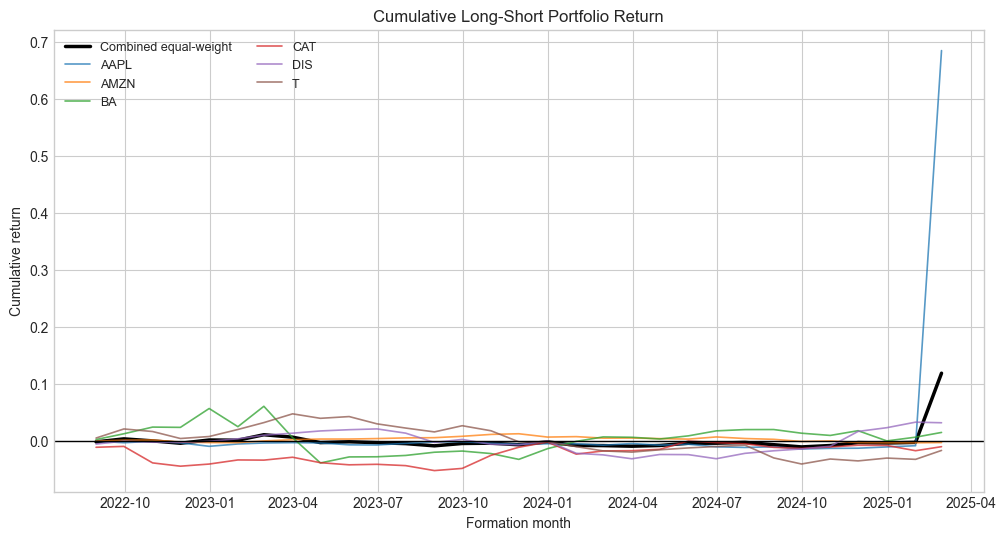

In [15]:
cumulative = combined_returns[["DATE", "portfolio_return"]].copy()
cumulative["combined"] = (1 + cumulative["portfolio_return"]).cumprod() - 1

issuer_cum = issuer_month_returns.pivot(index="DATE", columns="company_symbol", values="portfolio_return").sort_index()
issuer_cum = (1 + issuer_cum).cumprod() - 1

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(cumulative["DATE"], cumulative["combined"], color="black", linewidth=2.5, label="Combined equal-weight")
for issuer in SELECTED_ISSUERS:
    if issuer in issuer_cum.columns:
        ax.plot(issuer_cum.index, issuer_cum[issuer], linewidth=1.2, alpha=0.75, label=issuer)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Cumulative Long-Short Portfolio Return")
ax.set_xlabel("Formation month")
ax.set_ylabel("Cumulative return")
ax.legend(ncol=2, fontsize=9)
plt.show()

## Turnover and Duration Neutrality Checks

The duration-neutral condition is checked after scaling each issuer-month portfolio. Small residual values can remain because of floating-point precision.

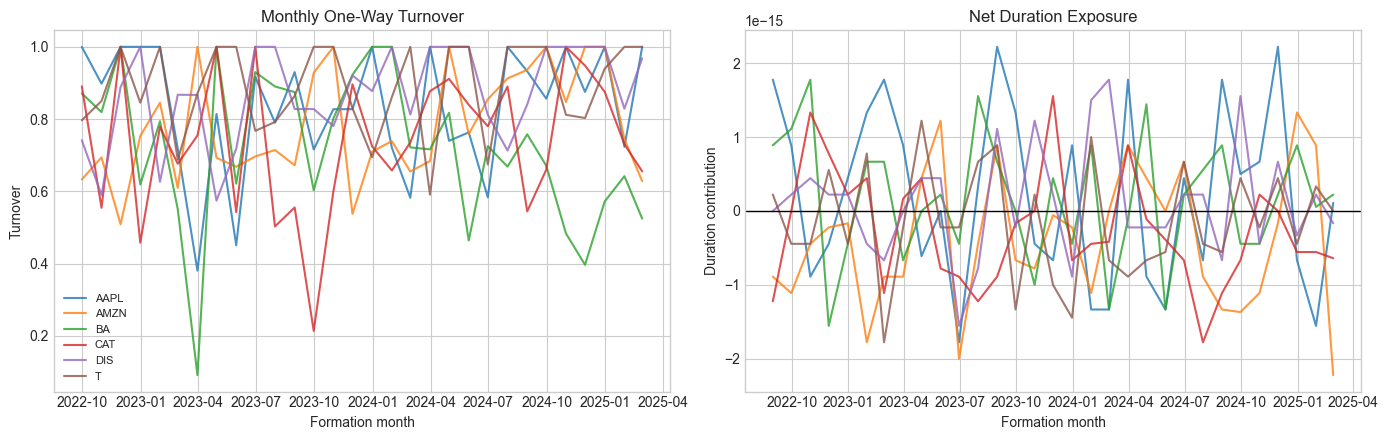

,max_abs_duration,avg_abs_duration,avg_turnover
company_symbol,,,
AAPL,0.0000,0.0000,0.8349
AMZN,0.0000,0.0000,0.7808
BA,0.0000,0.0000,0.7183
CAT,0.0000,0.0000,0.7418
DIS,0.0000,0.0000,0.8694
T,0.0000,0.0000,0.8893


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

for issuer, g in issuer_month_returns.groupby("company_symbol"):
    axes[0].plot(g["DATE"], g["turnover"], alpha=0.8, label=issuer)
axes[0].set_title("Monthly One-Way Turnover")
axes[0].set_xlabel("Formation month")
axes[0].set_ylabel("Turnover")
axes[0].legend(fontsize=8)

for issuer, g in issuer_month_returns.groupby("company_symbol"):
    axes[1].plot(g["DATE"], g["portfolio_duration"], alpha=0.8, label=issuer)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Net Duration Exposure")
axes[1].set_xlabel("Formation month")
axes[1].set_ylabel("Duration contribution")

fig.tight_layout()
plt.show()

display(
    issuer_month_returns.groupby("company_symbol").agg(
        max_abs_duration=("portfolio_duration", lambda x: x.abs().max()),
        avg_abs_duration=("portfolio_duration", lambda x: x.abs().mean()),
        avg_turnover=("turnover", "mean"),
    )
)

## Additional Outlier Review

The assignment asks whether outliers look systematically special. The table below summarizes the bonds most often selected as cheap or rich. This is useful because repeated selection can point to a persistent liquidity, coupon, maturity, or issue-size effect rather than a one-month noise observation.

In [17]:
selection_review = (
    positions.assign(
        cheap_count=lambda x: (x["side"] == "long cheap").astype(int),
        rich_count=lambda x: (x["side"] == "short rich").astype(int),
        abs_resid_bps=lambda x: x["resid_bps"].abs(),
    )
    .groupby(["company_symbol", "CUSIP", "MATURITY", "COUPON"])
    .agg(
        times_selected=("ISSUE_ID", "size"),
        times_cheap=("cheap_count", "sum"),
        times_rich=("rich_count", "sum"),
        avg_duration=("DURATION", "mean"),
        avg_spread_bps=("T_Spread_bps", "mean"),
        avg_abs_resid_bps=("abs_resid_bps", "mean"),
        median_dvolume=("T_DVolume_num", "median"),
        median_amount_outstanding=("AMOUNT_OUTSTANDING", "median"),
    )
    .reset_index()
    .sort_values(["times_selected", "avg_abs_resid_bps"], ascending=False)
    .head(20)
)
display(selection_review)

,company_symbol,CUSIP,MATURITY,COUPON,times_selected,times_cheap,times_rich,avg_duration,avg_spread_bps,avg_abs_resid_bps,median_dvolume,median_amount_outstanding
105,CAT,149123CD1,2044-05-15,4.3000,20,8,12,13.0270,34.6500,24.9439,"7,279,854.5000","500,000.0000"
55,AMZN,023135CK0,2062-04-13,4.1000,20,11,9,17.2340,40.1500,12.3397,"75,032,527.0000","1,250,000.0000"
152,DIS,25468PCX2,2042-12-01,3.7000,18,6,12,12.6639,22.5556,29.7968,"4,273,828.0000","500,000.0000"
96,CAT,149123BF7,2028-07-15,6.6250,18,13,5,3.9583,29.4444,22.6627,"2,242,998.0000","193,218.0000"
99,CAT,149123BL4,2035-09-15,5.3000,18,14,4,8.5789,37.7778,22.5765,"3,689,796.5000","307,320.0000"
48,AMZN,023135CC8,2061-05-12,3.2500,18,8,10,17.9006,35.9444,12.2818,"48,578,650.0000","1,750,000.0000"
65,BA,097023AN5,2043-10-15,6.8750,17,15,2,10.9129,142.6471,110.8788,"809,957.0000","125,000.0000"
97,CAT,149123BJ9,2031-05-01,7.3000,17,10,7,5.7547,40.0000,32.9938,"1,102,774.0000","242,226.0000"
87,BA,097023CW3,2050-05-01,5.8050,17,0,17,12.8200,19.6471,19.6352,"715,414,589.0000","5,500,000.0000"
46,AMZN,023135CA2,2041-05-12,2.8750,17,12,5,12.8041,36.7059,13.0579,"63,456,215.0000","2,000,000.0000"


## Findings

The cell below generates a concise write-up from the tables above. These findings should be reviewed before submission, but they are based directly on the executed calculations in this notebook.

In [18]:
combined = summary_table.loc["combined"]
best_issuer = issuer_summary["annualized_sharpe"].astype(float).idxmax()
worst_issuer = issuer_summary["annualized_sharpe"].astype(float).idxmin()
avg_duration_error = issuer_month_returns["portfolio_duration"].abs().mean()
avg_turnover = issuer_month_returns["turnover"].mean()
ret_source_share = filtered["next_return_source"].value_counts(normalize=True).to_dict()

finding_text = f"""
### Summary Write-up

The analysis uses {', '.join(SELECTED_ISSUERS)} from {START_DATE} through {END_DATE}. The consistency filter keeps the modal security level and rating category within each issuer-month, so the fitted spread curves compare bonds on the same seniority and rating basis.

The curve model explains the cross-section with duration, log-duration, and coupon. The fitted residual is interpreted as the relative-value signal: wider-than-fitted bonds are cheap and tighter-than-fitted bonds are rich. On {analysis_date.date()}, the largest residuals are shown in the rich/cheap table above. These outliers should not be treated as automatic trades without checking liquidity, amount outstanding, coupon level, and maturity concentration.

The monthly long-short strategy forms issuer-level portfolios by buying the cheapest bonds and shorting the richest bonds. The portfolio is scaled to make the market-value duration exposure close to zero. The average absolute net duration contribution is {avg_duration_error:.6f}, which indicates the duration-neutral constraint is working mechanically.

For the equal-weighted combined issuer portfolio, the total return is {combined['total_return']:.2%}, the annualized return is {combined['annualized_return']:.2%}, annualized volatility is {combined['annualized_volatility']:.2%}, and the annualized Sharpe ratio is {combined['annualized_sharpe']:.2f}. The average one-way monthly turnover is {avg_turnover:.2f}. Among the selected issuers, the strongest Sharpe ratio is for {best_issuer}, while the weakest is for {worst_issuer}.

Most next-month returns come from WRDS `RET_EOM` rather than the fallback price-plus-accrual approximation. The fallback exists only to avoid dropping otherwise usable observations when return data is missing.
"""

display(Markdown(finding_text))


### Summary Write-up

The analysis uses AAPL, AMZN, BA, CAT, DIS, T from 2022-08-31 through 2025-03-31. The consistency filter keeps the modal security level and rating category within each issuer-month, so the fitted spread curves compare bonds on the same seniority and rating basis.

The curve model explains the cross-section with duration, log-duration, and coupon. The fitted residual is interpreted as the relative-value signal: wider-than-fitted bonds are cheap and tighter-than-fitted bonds are rich. On 2025-03-31, the largest residuals are shown in the rich/cheap table above. These outliers should not be treated as automatic trades without checking liquidity, amount outstanding, coupon level, and maturity concentration.

The monthly long-short strategy forms issuer-level portfolios by buying the cheapest bonds and shorting the richest bonds. The portfolio is scaled to make the market-value duration exposure close to zero. The average absolute net duration contribution is 0.000000, which indicates the duration-neutral constraint is working mechanically.

For the equal-weighted combined issuer portfolio, the total return is 11.90%, the annualized return is 4.45%, annualized volatility is 7.70%, and the annualized Sharpe ratio is 0.58. The average one-way monthly turnover is 0.81. Among the selected issuers, the strongest Sharpe ratio is for AAPL, while the weakest is for T.

Most next-month returns come from WRDS `RET_EOM` rather than the fallback price-plus-accrual approximation. The fallback exists only to avoid dropping otherwise usable observations when return data is missing.


## Main Assumptions and Limitations

- `RET_EOM` is treated as the preferred monthly total return because it is the WRDS enhanced end-of-month return field.
- The fallback return uses price change plus one month of coupon accrual, which is only an approximation and does not fully reconstruct dirty-price returns.
- The spread curve is estimated separately by issuer and month. This avoids pooling very different issuers but creates noisier fits for months with fewer bonds.
- The strategy ignores transaction costs, shorting constraints, bid-ask spread, financing costs, and locate availability. Turnover is reported because those frictions would matter in practice.
- Volume weighting improves reliability but can underweight stale or small issues that may appear cheap because they are illiquid.
- A residual is a relative-value signal, not a complete credit view. Repeated outliers should be checked for liquidity, callable structure, issue size, coupon, downgrade/default concerns, and off-the-run effects.